=== Key Metrics ===
Total Revenue: $117,837.49
Total Orders: 500
Average Order Value: $235.67
Best-selling Product: Desk Lamp
Best-selling Category: Electronics

=== Top 5 Products by Revenue ===
                   total_revenue  total_quantity
product                                         
Desk Lamp               15089.48             176
Laptop Stand            14166.92             162
Water Bottle            12682.15             163
Bluetooth Speaker       12476.26             167
Yoga Mat                12463.96             162 

=== Category Performance ===
             total_revenue  total_quantity
category                                  
Electronics       45879.64             579
Sports            36267.27             478
Home              35690.58             451 

=== Monthly Sales Trends ===
     month   revenue  orders
0  2024-01  15277.70      70
1  2024-02  12686.61      48
2  2024-03  19173.55      70
3  2024-04  13878.03      59
4  2024-05  14959.85      73
5  2024-06

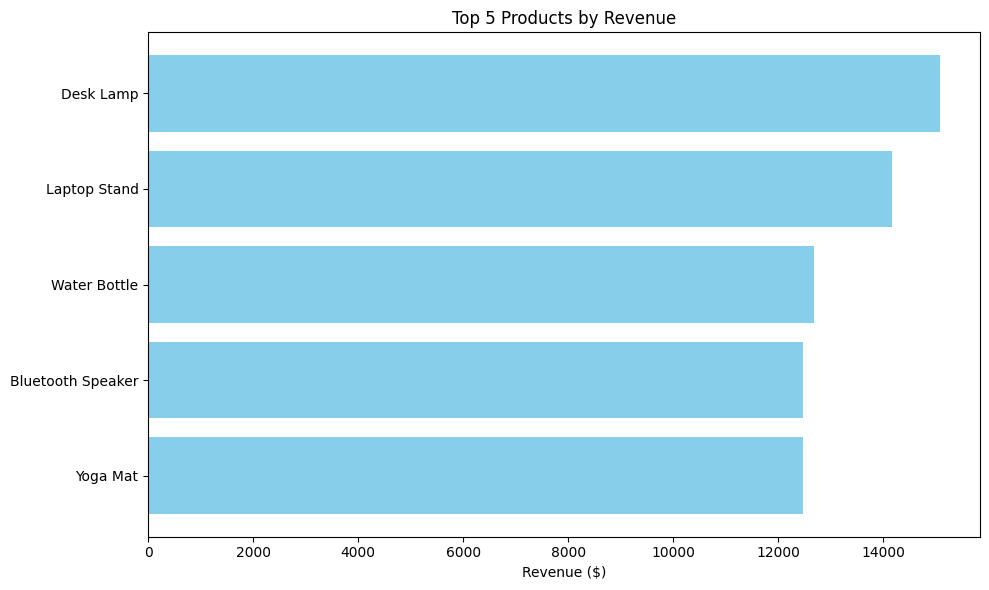

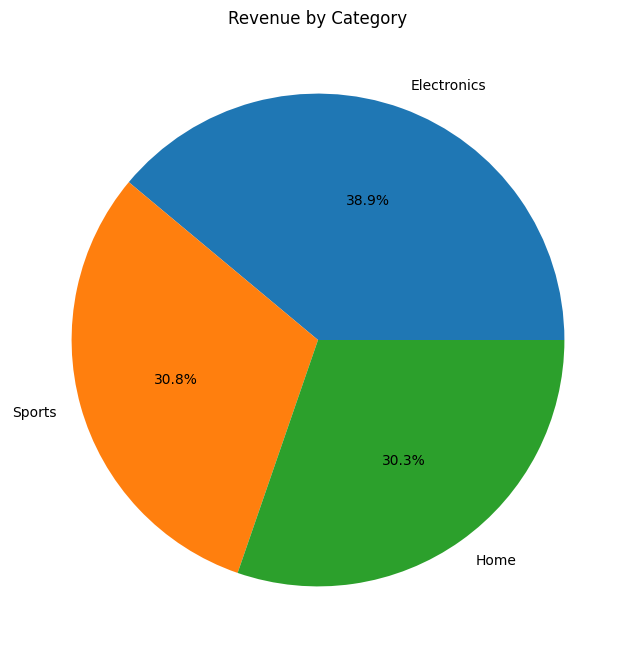

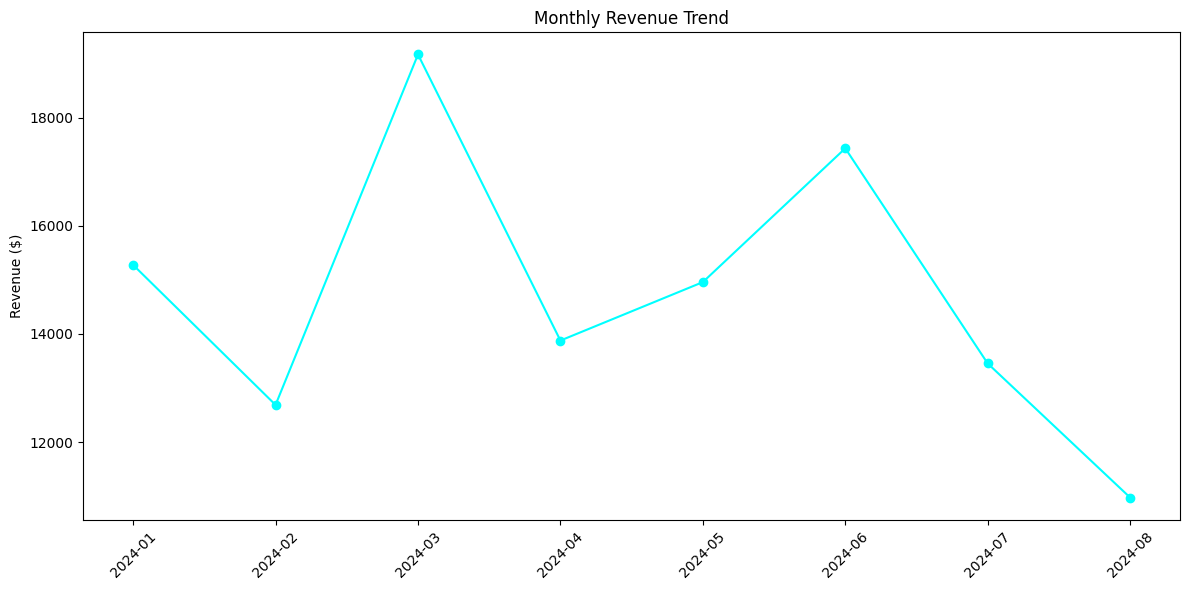

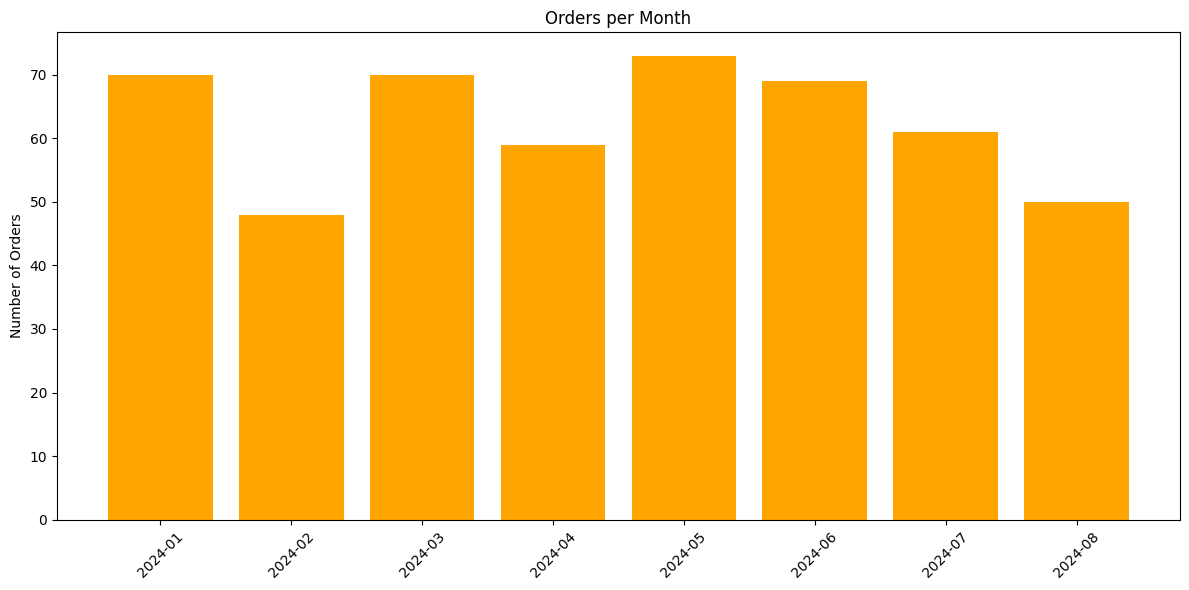

In [1]:
# E-commerce Dashboard using only Pandas, NumPy, and Matplotlib
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

products = [
    "Wireless Headphones", "Bluetooth Speaker", "Running Shoes",
    "Yoga Mat", "Coffee Mug", "Laptop Stand", "Water Bottle",
    "Desk Lamp", "Phone Case", "Kitchen Scale"
]

categories = {
    "Wireless Headphones": "Electronics",
    "Bluetooth Speaker": "Electronics",
    "Running Shoes": "Sports",
    "Yoga Mat": "Sports",
    "Coffee Mug": "Home",
    "Laptop Stand": "Electronics",
    "Water Bottle": "Sports",
    "Desk Lamp": "Home",
    "Phone Case": "Electronics",
    "Kitchen Scale": "Home"
}

num_orders = 500
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 8, 31)

data = []
for i in range(num_orders):
    product = random.choice(products)
    category = categories[product]
    price = round(random.uniform(10, 150), 2)
    quantity = random.randint(1, 5)
    random_days = random.randint(0, (end_date - start_date).days)
    date = start_date + timedelta(days=random_days)
    revenue = round(price * quantity, 2)
    
    data.append({
        "order_id": f"ORD-{i+1:04d}",
        "customer_id": f"CUST-{random.randint(1,200)}",
        "product": product,
        "category": category,
        "quantity": quantity,
        "price": price,
        "date": date.date(),
        "revenue": revenue
    })

df = pd.DataFrame(data)

# ------------------ Analysis ------------------
total_revenue = df['revenue'].sum()
total_orders = len(df)
avg_order_value = total_revenue / total_orders

product_group = df.groupby('product').agg(
    total_revenue=pd.NamedAgg(column='revenue', aggfunc='sum'),
    total_quantity=pd.NamedAgg(column='quantity', aggfunc='sum')
).sort_values('total_revenue', ascending=False)

best_product = product_group.index[0]

category_group = df.groupby('category').agg(
    total_revenue=pd.NamedAgg(column='revenue', aggfunc='sum'),
    total_quantity=pd.NamedAgg(column='quantity', aggfunc='sum')
).sort_values('total_revenue', ascending=False)

best_category = category_group.index[0]

df['month'] = pd.to_datetime(df['date']).dt.to_period('M')
monthly_trends = df.groupby('month').agg(
    revenue=pd.NamedAgg(column='revenue', aggfunc='sum'),
    orders=pd.NamedAgg(column='order_id', aggfunc='count')
).reset_index()

# ------------------ Display Metrics ------------------
print("=== Key Metrics ===")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Best-selling Product: {best_product}")
print(f"Best-selling Category: {best_category}\n")

print("=== Top 5 Products by Revenue ===")
print(product_group.head(5), "\n")

print("=== Category Performance ===")
print(category_group, "\n")

print("=== Monthly Sales Trends ===")
print(monthly_trends, "\n")

print("=== Sample Data Preview (First 10 Records) ===")
print(df.head(10))

# ------------------ Visualization (Matplotlib only) ------------------
# Top 5 Products by Revenue
plt.figure(figsize=(10,6))
plt.barh(product_group.head(5).index[::-1], product_group.head(5)['total_revenue'][::-1], color='skyblue')
plt.xlabel("Revenue ($)")
plt.title("Top 5 Products by Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,8))
plt.pie(category_group['total_revenue'], labels=category_group.index, autopct='%1.1f%%', colors=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title("Revenue by Category")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(monthly_trends['month'].astype(str), monthly_trends['revenue'], marker='o', color='cyan')
plt.xticks(rotation=45)
plt.ylabel("Revenue ($)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.bar(monthly_trends['month'].astype(str), monthly_trends['orders'], color='orange')
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.title("Orders per Month")
plt.tight_layout()
plt.show()
